In [2]:
import numpy as np
import pandas as pd
import xarray as xr

import os
from copy import copy

import analysis_tools as tool
from config import *

%matplotlib inline
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.patches import Rectangle
import matplotlib.patheffects as path_effects
import matplotlib.transforms as mtransforms

In [3]:
grid_data = tool.load_grid_data()

# T2m temperature difference between CTL and dry run

In [5]:
dts = pd.date_range(start="2021-07-13T00", end="2021-07-15T00", freq="3h")

base_dir = "/automount/agh/s6tifohr/july21_eval/data"


ds_t2m_ctl = tool.read_merged_var_det("t2m", dts, f"{base_dir}/BLK_CTL/merged/t2m", accu=False)
ds_t2m_ens_ctl = tool.read_merged_var_ens("t2m", dts, f"{base_dir}/BLK_CTL/merged/t2m", accu=False)

ds_t2m_wlt = tool.read_merged_var_det("t2m", dts, f"{base_dir}/BLK_WLT/merged/t2m", accu=False)
ds_t2m_ens_wlt = tool.read_merged_var_ens("t2m", dts, f"{base_dir}/BLK_WLT/merged/t2m", accu=False)

ds_t2m_sat = tool.read_merged_var_det("t2m", dts, f"{base_dir}/BLK_SAT/merged/t2m", accu=False)
ds_t2m_ens_sat = tool.read_merged_var_ens("t2m", dts, f"{base_dir}/BLK_SAT/merged/t2m", accu=False)

ecCodes provides no latitudes/longitudes for gridType='unstructured_grid'
ecCodes provides no latitudes/longitudes for gridType='unstructured_grid'


In [6]:
(ds_t2m_wlt - ds_t2m_ctl).sel(cell=grid_data["focus_cells_26_red"]).sel(step=ds_t2m_ctl["step"].dt.hour.isin(range(8,18))).mean()

<xarray.DataArray 't2m' ()> Size: 4B
np.float32(1.5214214)
Coordinates:
    heightAboveGround  float64 8B 2.0

In [16]:
(ds_t2m_ens_wlt - ds_t2m_ens_ctl).sel(cell=grid_data["focus_cells_28"], step=ds_t2m_ens_ctl["step"].dt.hour.isin(range(8,18))).mean(dim=["step", "cell"]).std()

<xarray.DataArray 't2m' ()> Size: 8B
array(0.98733169)
Coordinates:
    heightAboveGround  float64 8B 2.0

# Humidity

In [16]:
dts = pd.date_range(start="2021-07-13T00", end="2021-07-15T21", freq="3h")
base_dir = "/automount/agh/s6tifohr/july21_eval/data"

ds_q_ctl = tool.read_merged_var_det("q", dts, f"{base_dir}/BLK_CTL/merged/q", accu=False)
ds_q_wlt = tool.read_merged_var_det("q", dts, f"{base_dir}/BLK_WLT/merged/q", accu=False)
ds_q_sat = tool.read_merged_var_det("q", dts, f"{base_dir}/BLK_SAT/merged/q", accu=False)

In [54]:
hhl = xr.open_dataset("invar/det_hhl_dom1cut.grb", engine="cfgrib", backend_kwargs={"indexpath": None})["HHL"]
# Average adjacent half levels → full model level heights, assign generalVerticalLayer coord
hml = xr.DataArray(
    0.5 * (hhl.isel(generalVertical=slice(None, -1)).values + hhl.isel(generalVertical=slice(1, None)).values),
    dims=["generalVerticalLayer", "cell"],
    coords={"generalVerticalLayer": hhl["generalVertical"].values[:-1]},
)

hhl_ens = xr.open_dataset("invar/ens_hhl_dom2.grb", engine="cfgrib", backend_kwargs={"indexpath": None})["HHL"]
# Average adjacent half levels → full model level heights, assign generalVerticalLayer coord
hml_ens = xr.DataArray(
    0.5 * (hhl_ens.isel(generalVertical=slice(None, -1)).values + hhl_ens.isel(generalVertical=slice(1, None)).values),
    dims=["generalVerticalLayer", "cell"],
    coords={"generalVerticalLayer": hhl_ens["generalVertical"].values[:-1]},
)

ecCodes provides no latitudes/longitudes for gridType='unstructured_grid'


In [ ]:
# Select only the levels present in the cut ds_q
hml_q = hml.sel(generalVerticalLayer=ds_q_ctl["generalVerticalLayer"])

ds_q_ctl_bl = ds_q_ctl.where(hml_q < 1500)#.sel(cell=grid_data["focus_cells_26_red"])
ds_q_wlt_bl = ds_q_wlt.where(hml_q < 1500)#.sel(cell=grid_data["focus_cells_26_red"])
ds_q_sat_bl = ds_q_sat.where(hml_q < 1500)#.sel(cell=grid_data["focus_cells_26_red"])

In [14]:
(ds_q_wlt_1km.mean() - ds_q_ctl_1km.mean()) / ds_q_ctl_1km.mean()

<xarray.DataArray 'q' ()> Size: 4B
np.float32(0.006856158)

In [15]:
(ds_q_sat_1km.mean() - ds_q_ctl_1km.mean()) / ds_q_ctl_1km.mean()

<xarray.DataArray 'q' ()> Size: 4B
np.float32(0.054703757)

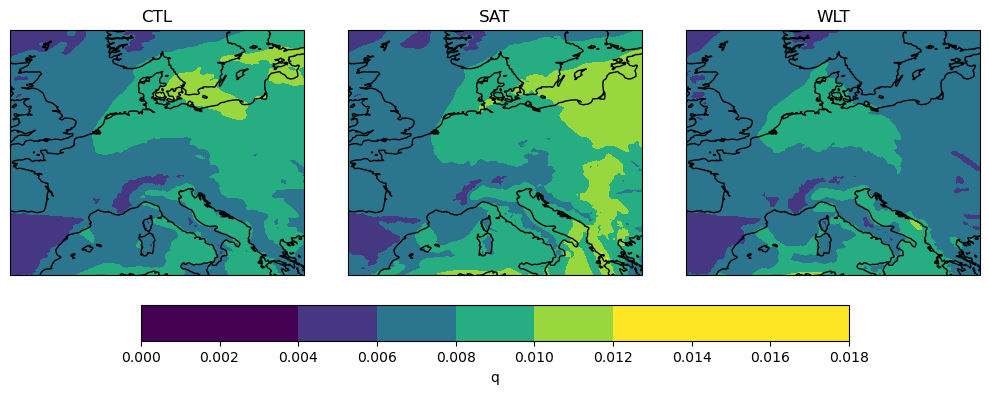

In [29]:
x0, x1, y0, y1 = PLOT_WINDOW
in_window = (
    (np.rad2deg(grid_data["grid_26_red"]["clon"].values) >= x0) &
    (np.rad2deg(grid_data["grid_26_red"]["clon"].values) <= x1) &
    (np.rad2deg(grid_data["grid_26_red"]["clat"].values) >= y0) &
    (np.rad2deg(grid_data["grid_26_red"]["clat"].values) <= y1)
)

data_ctl = ds_q_ctl.mean(dim=["step", "generalVerticalLayer"])
data_sat = ds_q_sat.mean(dim=["step", "generalVerticalLayer"])
data_wlt = ds_q_wlt.mean(dim=["step", "generalVerticalLayer"])

vmin = min(data_ctl[in_window].min(), data_sat[in_window].min(), data_wlt[in_window].min()).item()
vmax = max(data_ctl[in_window].max(), data_sat[in_window].max(), data_wlt[in_window].max()).item()

fig, axs = plt.subplots(1, 3, figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})
fig.tight_layout(w_pad=3.2, h_pad=1.)

for ax, data, title in zip(axs, [data_ctl, data_sat, data_wlt], ["CTL", "SAT", "WLT"]):
    im = ax.tricontourf(grid_data["tri_26_red"], data, vmin=vmin, vmax=vmax)
    ax.set(title=title)
    ax.set_extent(PLOT_WINDOW, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE)

fig.colorbar(im, ax=axs, orientation="horizontal", fraction=0.046, pad=0.04, label="q")
plt.show()

In [39]:
dts = pd.date_range(start="2021-07-13T00", end="2021-07-15T21", freq="3h")
base_dir = "/automount/agh/s6tifohr/july21_eval/data"

ds_rh_ctl = tool.read_merged_var_det("rh", dts, f"{base_dir}/BLK_CTL/merged/rh", accu=False, format="netcdf")
ds_rh_ens_ctl = tool.read_merged_var_ens("rh", dts, f"{base_dir}/BLK_CTL/merged/rh", accu=False, format="netcdf")

ds_rh_wlt = tool.read_merged_var_det("rh", dts, f"{base_dir}/BLK_WLT/merged/rh", accu=False, format="netcdf")
ds_rh_ens_wlt = tool.read_merged_var_ens("rh", dts, f"{base_dir}/BLK_WLT/merged/rh", accu=False, format="netcdf")

ds_rh_sat = tool.read_merged_var_det("rh", dts, f"{base_dir}/BLK_SAT/merged/rh", accu=False, format="netcdf")
ds_rh_ens_sat = tool.read_merged_var_ens("rh", dts, f"{base_dir}/BLK_SAT/merged/rh", accu=False, format="netcdf")

In [52]:
len(grid_data["focus_cells_28"])

75948

In [51]:
hml_ens.sel(generalVerticalLayer=ds_rh_ens_ctl["generalVerticalLayer"])

<xarray.DataArray (generalVerticalLayer: 74, cell: 659156)> Size: 195MB
array([[2.2433449e+04, 2.2433449e+04, 2.2433449e+04, ..., 2.2433449e+04,
        2.2433449e+04, 2.2433449e+04],
       [2.1766027e+04, 2.1766027e+04, 2.1766027e+04, ..., 2.1766027e+04,
        2.1766027e+04, 2.1766027e+04],
       [2.1115297e+04, 2.1115297e+04, 2.1115297e+04, ..., 2.1115297e+04,
        2.1115297e+04, 2.1115297e+04],
       ...,
       [9.5564560e+01, 9.5564560e+01, 9.5564560e+01, ..., 9.5564560e+01,
        9.5564560e+01, 9.5564560e+01],
       [4.2060852e+01, 4.2060852e+01, 4.2060852e+01, ..., 4.2060852e+01,
        4.2060852e+01, 4.2060852e+01],
       [9.9788513e+00, 9.9788513e+00, 9.9788513e+00, ..., 9.9788513e+00,
        9.9788513e+00, 9.9788513e+00]], dtype=float32)
Coordinates:
  * generalVerticalLayer  (generalVerticalLayer) float64 592B 1.0 2.0 ... 74.0
Dimensions without coordinates: cell

In [61]:
hml_rh = hml.sel(generalVerticalLayer=ds_rh_ctl["generalVerticalLayer"], cell=grid_data["focus_cells_26_red"])
hml_rh_ens = hml_ens.sel(generalVerticalLayer=ds_rh_ens_ctl["generalVerticalLayer"], cell=grid_data["focus_cells_28"])

ds_rh_ctl_bl = ds_rh_ctl.where(hml_rh < 1500)
ds_rh_ens_ctl_bl = ds_rh_ens_ctl.where(hml_rh_ens < 1500)

ds_rh_wlt_bl = ds_rh_wlt.where(hml_rh < 1500)
ds_rh_ens_wlt_bl = ds_rh_ens_wlt.where(hml_rh_ens < 1500)

ds_rh_sat_bl = ds_rh_sat.where(hml_rh < 1500)
ds_rh_ens_sat_bl = ds_rh_ens_sat.where(hml_rh_ens < 1500)

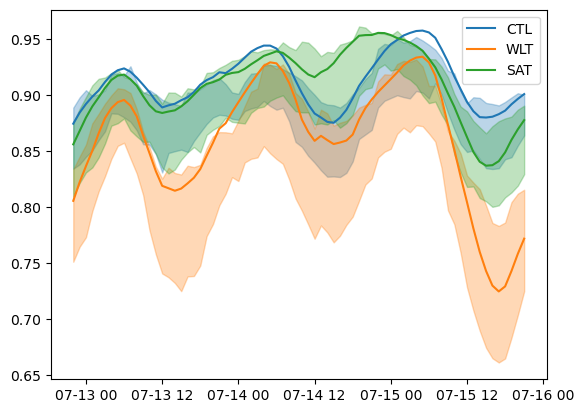

In [62]:
plt.plot(ds_rh_ctl_bl["step"], ds_rh_ctl_bl.mean(dim=["cell", "generalVerticalLayer"]), label="CTL", color=c_ctl)
plt.fill_between(ds_rh_ctl_bl["step"], 
                 ds_rh_ens_ctl_bl.mean(dim=["cell", "generalVerticalLayer"]).quantile(0.25, dim="mem"), 
                 ds_rh_ens_ctl_bl.mean(dim=["cell", "generalVerticalLayer"]).quantile(0.75, dim="mem"), color=c_ctl, alpha=0.3)

plt.plot(ds_rh_wlt_bl["step"], ds_rh_wlt_bl.mean(dim=["cell", "generalVerticalLayer"]), label="WLT", color=c_dry)
plt.fill_between(ds_rh_wlt_bl["step"], 
                 ds_rh_ens_wlt_bl.mean(dim=["cell", "generalVerticalLayer"]).quantile(0.25, dim="mem"), 
                 ds_rh_ens_wlt_bl.mean(dim=["cell", "generalVerticalLayer"]).quantile(0.75, dim="mem"), color=c_dry, alpha=0.3)

plt.plot(ds_rh_sat_bl["step"], ds_rh_sat_bl.mean(dim=["cell", "generalVerticalLayer"]), label="SAT", color=c_wet)
plt.fill_between(ds_rh_sat_bl["step"], 
                 ds_rh_ens_sat_bl.mean(dim=["cell", "generalVerticalLayer"]).quantile(0.25, dim="mem"), 
                 ds_rh_ens_sat_bl.mean(dim=["cell", "generalVerticalLayer"]).quantile(0.75, dim="mem"), color=c_wet, alpha=0.3)

plt.legend()
plt.show()

In [64]:
ds_rh_wlt_bl.mean() - ds_rh_ctl_bl.mean()

<xarray.DataArray 'rh' ()> Size: 4B
np.float32(-0.05237794)

In [69]:
(ds_rh_ens_wlt_bl.mean(dim=["step", "generalVerticalLayer", "cell"]) - ds_rh_ens_ctl_bl.mean(dim=["step", "generalVerticalLayer", "cell"])).mean()

<xarray.DataArray 'rh' ()> Size: 4B
np.float32(-0.05809457)

In [70]:
(ds_rh_ens_wlt_bl.mean(dim=["step", "generalVerticalLayer", "cell"]) - ds_rh_ens_ctl_bl.mean(dim=["step", "generalVerticalLayer", "cell"])).std()

<xarray.DataArray 'rh' ()> Size: 8B
array(0.03071197)